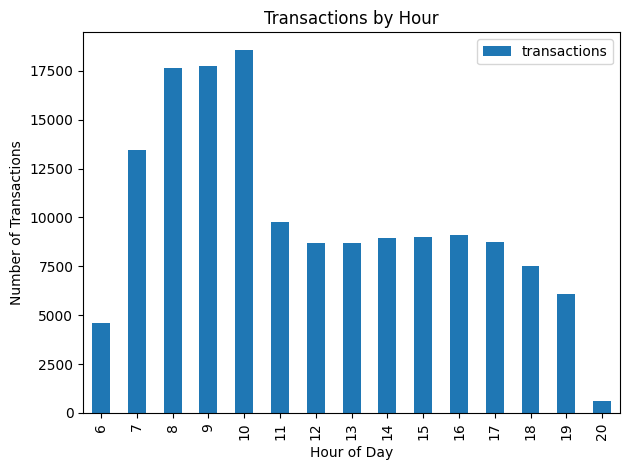

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../data/Coffee_shop_sales.xlsx")

df.head()

# Computing revenue (quantity * unit price)
df["revenue"] = df["transaction_qty"] * df["unit_price"]

#.to_datetime pandas library used to convert input types like strings into datetime objects

df["transaction_time"] = pd.to_datetime(
    df["transaction_time"].astype(str),
    format= "%H:%M:%S", 
    errors = "coerce"
)

# Drop any bad rows
df = df.dropna(subset=["transaction_time"])

# Extract hour from transaction_time
df["hour"] = df["transaction_time"].dt.hour

df["hour_label"] = df["transaction_time"].dt.strftime("%I %p")
# Group data by hour to analyze sales by time of day
hourly = df.groupby(["hour", "hour_label"])["revenue"].agg(["count","sum"]).reset_index()

hourly = hourly.rename(columns={
    "count": "transactions",
    "sum": "revenue"
})

# Sorting data by transactions to find peak hours
hourly =hourly.sort_values("hour")

# display the hourly data
hourly

# -- Visualizations --
# Bar chart for trasactions by hour

hourly.plot( x = "hour", y = "transactions", kind= "bar")

plt.title ("Transactions by Hour")
plt.xlabel ("Hour of Day")
plt.ylabel ("Number of Transactions")

# function in Matplotlib that fixes subplot parameters so it fits neatly

plt.tight_layout()
plt.show()
